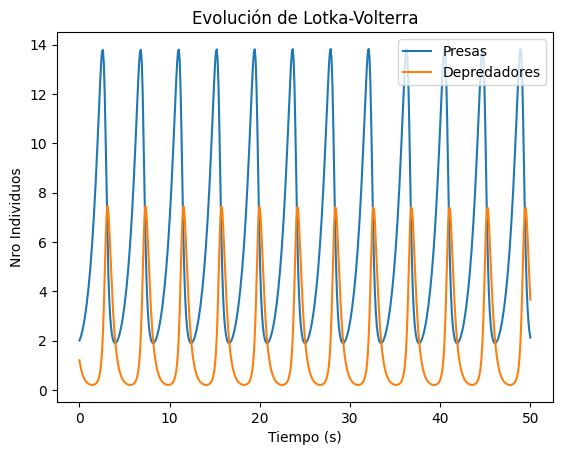

In [2]:
# SIMULACION DE LOTKA-VOLTERRA CON RK4
import numpy as np
import matplotlib.pyplot as plt

alpha = 1.0
beta = 0.5
delta = 0.5
gamma = 3.0

Nt = 500
T = 50.0
time = np.linspace(0, T, Nt)
dt = time[1] - time[0]

x = np.zeros((Nt, 2))
x0 = [2.0, 1.2]
x[0] = x0

def f(x):
  x1, x2 = x
  dx1dt = alpha * x1 - beta * x1 * x2
  dx2dt = delta * x1 * x2 - gamma * x2
  return np.array([dx1dt, dx2dt])

for k in range(Nt-1):
  x1, x2 = x[k]
  k1 = f(x[k])
  k2 = f(x[k] + 0.5 * dt * k1)
  k3 = f(x[k] + 0.5 * dt * k2)
  k4 = f(x[k] + dt * k3)
  x[k+1] = x[k] + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

plt.plot(time, x[:,0], label="Presas")
plt.plot(time, x[:,1], label="Depredadores")
plt.xlabel("Tiempo (s)")
plt.ylabel("Nro Individuos")
plt.title("Evolución de Lotka-Volterra")
plt.legend(loc="upper right")
plt.show()

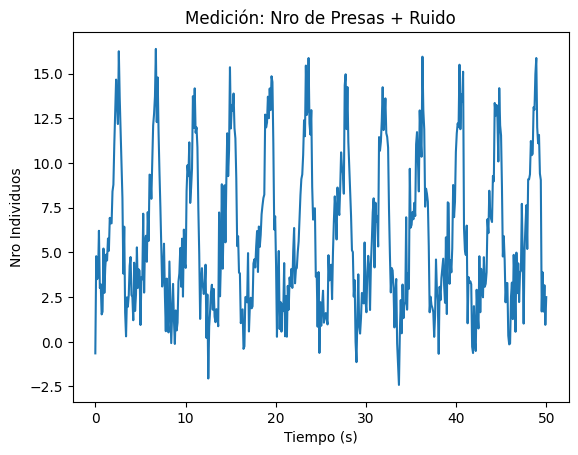

In [3]:
# SIMULAR OBSERVACIÓN DE X1 (PRESAS) CON RUIDO
X_real = np.copy(x)
sigma = 0.5
dW = np.random.normal(0, np.sqrt(dt), Nt)

dY = X_real[:, 0] * dt + sigma * dW
plt.plot(time, dY / dt)
plt.xlabel("Tiempo (s)")
plt.ylabel("Nro Individuos")
plt.title("Medición: Nro de Presas + Ruido")
plt.show()

In [4]:
# FILTRO DE PARTICULAS (BASADO EN LA ECUACION DE ZAKAI)
N = 2000 # Nro de particulas
P = np.random.uniform(low=[0.0, 0.0], high=[15.0, 5.0], size=(N, 2))
w = np.ones(N) / N

sigma_P = 0.25
history_P = np.zeros((Nt, N, 2))
for k in range(Nt-1):
  # PASO 1: AVANZAR PARTICULAS EN EL MODELO
  k1 = np.array(list(map(f, P)))
  k2 = np.array(list(map(f, P + 0.5 * dt * k1)))
  k3 = np.array(list(map(f, P + 0.5 * dt * k2)))
  k4 = np.array(list(map(f, P + dt * k3)))
  dPdt = (1.0 / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
  dWP = np.random.normal(0, np.sqrt(dt), (N, 2))
  P = np.clip(P + dt * dPdt + sigma_P * dWP, 1e-7, 1e3)

  # PASO 2: ACTUALIZACION ZAKAI DE LOS PESOS
  inno = dY[k] - P[:,0] * dt
  lkhood = np.exp(- inno**2 / (2 * sigma**2 * dt))
  w *= lkhood
  w /= np.sum(w)

  # PASO 3: GENERACION DE NUEVAS PARTICULAS
  N_eff = 1.0 / np.sum(w**2)
  if N_eff < N / 2:
    indexes = np.random.choice(N, size=N, p=w)
    P = P[indexes]
    w = np.ones(N) / N

  history_P[k] = P.copy()

history_P[-1] = P.copy()

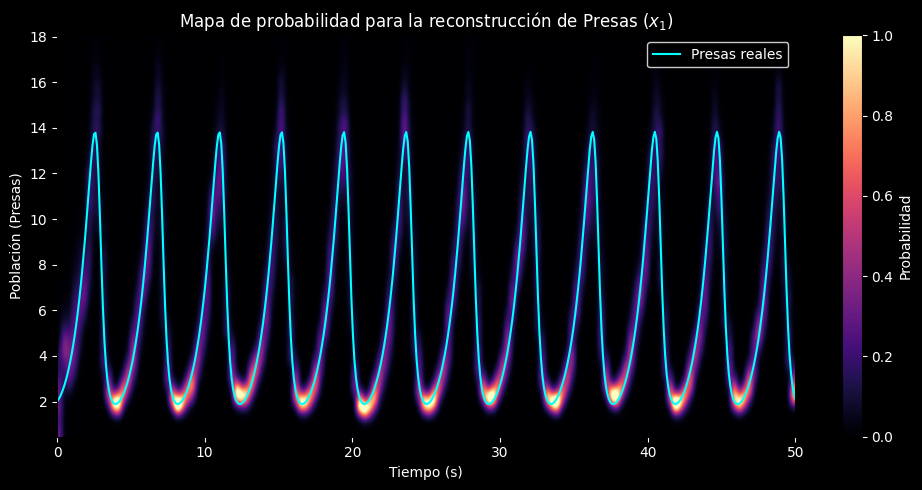

In [9]:
# GRAFICAR MAPA DE PROBABILIDAD PARA PRESAS
plt.figure(figsize=(10, 5))
ax = plt.gca()
ax.set_facecolor('black')
plt.gcf().patch.set_facecolor('black')

timesP = np.repeat(time, N)
x1P = history_P[:, :, 0].flatten()

y_lower = np.percentile(x1P, 0.1)
y_upper = np.percentile(x1P, 99.9)
mask = (x1P >= y_lower) & (x1P <= y_upper)

counts, xedges, yedges = np.histogram2d(timesP[mask], x1P[mask], bins=[150, 60])
probs = counts / N
im = plt.imshow(probs.T, origin='lower',
                extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                aspect='auto', cmap='magma', interpolation='bicubic', vmin=0, vmax=1.0)

plt.plot(time, X_real[:, 0], color='cyan', label='Presas reales')

ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')

cbar = plt.colorbar(im)
cbar.set_label("Probabilidad", color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax, 'yticklabels'), color='white')

plt.title("Mapa de probabilidad para la reconstrucción de Presas ($x_1)$")
plt.xlabel("Tiempo (s)")
plt.ylabel("Población (Presas)")
plt.legend(facecolor='black', edgecolor='white', labelcolor='white')
plt.tight_layout()
plt.show()

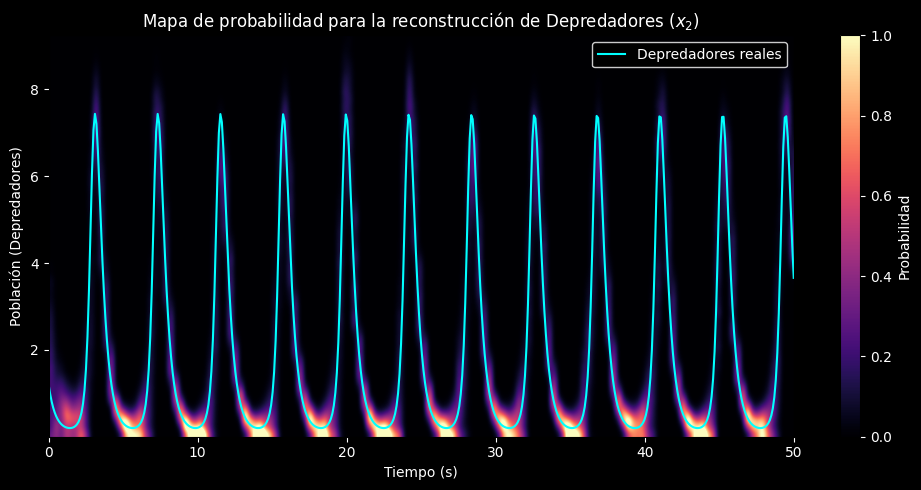

In [8]:
# GRAFICAR MAPA DE PROBABILIDAD PARA DEPREDADORES
plt.figure(figsize=(10, 5))
ax = plt.gca()
ax.set_facecolor('black')
plt.gcf().patch.set_facecolor('black')

timesP = np.repeat(time, N)
x2P = history_P[:, :, 1].flatten()

y_lower = np.percentile(x2P, 0.01)
y_upper = np.percentile(x2P, 99.99)
mask = (x2P >= y_lower) & (x2P <= y_upper)

counts, xedges, yedges = np.histogram2d(timesP[mask], x2P[mask], bins=[150, 60])
probs = counts / N
im = plt.imshow(probs.T, origin='lower',
                extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                aspect='auto', cmap='magma', interpolation='bicubic', vmin=0, vmax=1.0)

plt.plot(time, X_real[:, 1], color='cyan', label='Depredadores reales')

ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')

cbar = plt.colorbar(im)
cbar.set_label("Probabilidad", color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax, 'yticklabels'), color='white')

plt.title("Mapa de probabilidad para la reconstrucción de Depredadores ($x_2)$")
plt.xlabel("Tiempo (s)")
plt.ylabel("Población (Depredadores)")
plt.legend(facecolor='black', edgecolor='white', labelcolor='white')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Medición: Nro de Presas + Ruido + Desfase')

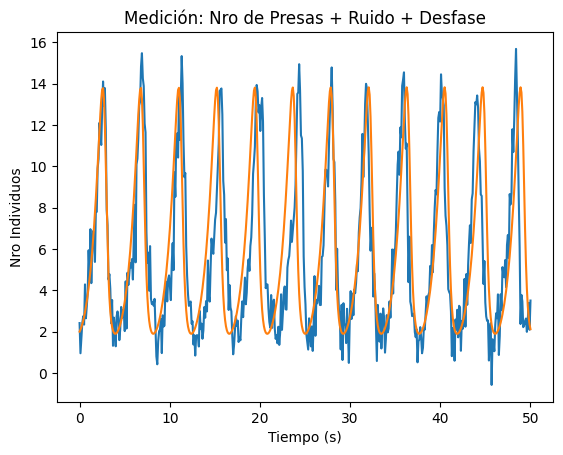

In [10]:
# ADICIONAL: OBSERVACION CON PHASE DRIFT
X_real = np.copy(x)
sigma = 0.25
sigma_phase = 0.2
dtheta = np.cumsum(sigma_phase * np.random.normal(0, np.sqrt(dt), Nt))

dW = np.random.normal(0, np.sqrt(dt), Nt)
time_drifted = np.clip(time + dtheta, time[0], time[-1])
X_drifted = np.interp(time_drifted, time, X_real[:, 0])
dY = X_drifted * dt + sigma * dW

plt.plot(time, dY / dt)
plt.plot(time, X_real[:, 0])
plt.xlabel("Tiempo (s)")
plt.ylabel("Nro Individuos")
plt.title("Medición: Nro de Presas + Ruido + Desfase")